# 🤖 Modelos Locales e Inferencia con Gemma 4
### UAG — Deep Learning · Semana 2 · Miércoles (1h)

> **Pregunta de arranque**: ¿Qué necesitas para correr ChatGPT en tu propia computadora?
> ¿Es siquiera posible? ¿A qué costo?

Hoy vas a correr un modelo de lenguaje de última generación **completamente local** — sin API, sin nube, sin costos por token.


## 0. Imports

In [2]:
import ollama
import subprocess
import textwrap
from pathlib import Path
from IPython.display import Image, display, Markdown

# Ruta a la imagen para el demo multimodal (relativa al notebook)
IMG_PATH = Path("local/assets/sample_images/arcane.jpg")

# Modelo a usar — cambiar a "gemma4:e4b" si tienes más VRAM
MODEL = "gemma4:e4b"

print(f"Modelo configurado : {MODEL}")
print(f"Imagen para demo   : {IMG_PATH} ({'OK' if IMG_PATH.exists() else 'NO ENCONTRADA'})")


Modelo configurado : gemma4:e4b
Imagen para demo   : local\assets\sample_images\arcane.jpg (OK)


## 1. ¿Cómo funciona Ollama? La arquitectura en 30 segundos

Cuando hacemos `import ollama` y llamamos a `ollama.chat(...)`, esto es lo que ocurre:

```
Tu notebook (Python)
       │
       │  HTTP/REST  →  localhost:11434
       ▼
 Servidor Ollama     ← corre en segundo plano como servicio
       │
       │  lee pesos cuantizados (4-8 bits en lugar de 32 bits)
       ▼
 Modelo en VRAM/RAM  (gemma4:e2b = ~7.2 GB)
       │
       │  genera tokens uno por uno (autoregresivo)
       ▼
 Respuesta de texto
```

> **¿Por qué cuantización?** El modelo original de Gemma 4 E2B ocupa ~14 GB en float32. Con cuantización Q4 (4 bits por parámetro), baja a ~7 GB manteniendo >95% de la calidad. Es el mismo truco que se usa para comprimir imágenes sin pérdida perceptible.


### Verificar que Ollama está corriendo

In [3]:
# Ver modelos descargados localmente
result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(result.stdout)

NAME          ID              SIZE      MODIFIED    
gemma4:e4b    c6eb396dbd59    9.6 GB    2 hours ago    



## 2. Primera inferencia: el "Hola mundo" del LLM

La API de Ollama sigue el formato de OpenAI (`messages` con roles), que ya es el estándar de facto de la industria.


In [4]:
# --- Prompt completo visible (sin magia negra) ---
mensajes = [
    {
        "role": "user",
        "content": "Explica en exactamente 2 oraciones qué es el Aprendizaje Profundo (Deep Learning)."
    }
]

print("=" * 60)
print("PROMPT ENVIADO AL MODELO:")
print("=" * 60)
for m in mensajes:
    print(f"[{m['role'].upper()}] {m['content']}")
print("=" * 60)
print()

respuesta = ollama.chat(model=MODEL, messages=mensajes)

print("RESPUESTA DEL MODELO:")
print("=" * 60)
print(respuesta.message.content)
print("=" * 60)
print(f"\nTokens usados — Prompt: {respuesta.prompt_eval_count} | "
      f"Respuesta: {respuesta.eval_count} | "
      f"Total: {respuesta.prompt_eval_count + respuesta.eval_count}")


PROMPT ENVIADO AL MODELO:
[USER] Explica en exactamente 2 oraciones qué es el Aprendizaje Profundo (Deep Learning).

RESPUESTA DEL MODELO:
El Aprendizaje Profundo (Deep Learning) es un subcampo avanzado del aprendizaje automático que utiliza redes neuronales artificiales con múltiples capas interconectadas. Estas capas permiten al sistema identificar patrones complejos y representaciones jerárquicas directamente desde grandes volúmenes de datos, impulsando capacidades como el reconocimiento de voz y la visión por computadora.

Tokens usados — Prompt: 34 | Respuesta: 357 | Total: 391


## 3. Parámetros de generación: controlando la "creatividad"

El modelo no es determinista por defecto. Tres parámetros controlan qué tan predecible o creativo es:

| Parámetro | Efecto | Valor bajo | Valor alto |
|-----------|--------|-----------|-----------|
| `temperature` | Aleatoriedad general | Repetitivo, seguro | Creativo, impredecible |
| `top_p` | Núcleo de probabilidad acumulada | Solo tokens muy probables | Considera más opciones |
| `top_k` | Máximo de tokens candidatos | Respuestas más enfocadas | Más variedad léxica |

> **Recomendación Google para Gemma 4**: `temperature=1.0`, `top_p=0.95`, `top_k=64`


In [5]:
PREGUNTA = "Dame cinco nombres creativos para una startup de inteligencia artificial en México. No necesito explicaciones largas sólo el nombre y una pequeña oración del porqué"

def inferir(temperatura: float) -> str:
    r = ollama.chat(
        model=MODEL,
        messages=[{"role": "user", "content": PREGUNTA}],
        options={"temperature": temperatura, "top_p": 0.95, "top_k": 64}
    )
    return r.message.content.strip()

print(f"Pregunta: {PREGUNTA}\n")
print(f"{'─'*55}")

for temp in [0.1, 1.0, 2.0]:
    respuesta = inferir(temp)
    print(f"temperature={temp}: {respuesta}")
    print(f"{'─'*55}")

print("\n Observa: baja temperatura = respuestas similares entre corridas.")
print("Alta temperatura = más variedad (y a veces más errores).")


Pregunta: Dame un nombre creativo para una startup de inteligencia artificial en México. No necesito explicaciones largas sólo el nombre y una pequeña oración del porqué

───────────────────────────────────────────────────────
temperature=0.1: **1. Tlazcal AI**
(Tlazcal es una raíz náhuatl que significa "brillar" o "resplandecer"). Sugiere que la inteligencia artificial es la luz que guiará el futuro de México.

**2. Vértice Data**
(Vértice significa el punto más alto o el cruce de caminos). Implica que la startup es el punto de convergencia de la información y la innovación.

**3. Códice IA**
(Códice hace referencia a un libro antiguo de conocimiento). Posiciona a la empresa como la guardiana y creadora de conocimiento avanzado y estructurado.

**4. Synapsis MX**
(Synapsis es la conexión entre neuronas). Es un nombre globalmente reconocido en tecnología, pero el sufijo MX lo ancla inmediatamente al mercado mexicano.

**5. Origen Cognitivo**
Es un nombre más descriptivo y formal. Trans

## 4. System Prompt: dándole personalidad al modelo

El rol `system` permite establecer el **contexto, personalidad y restricciones** del modelo antes de que el usuario hable.
Es la forma en que productos como ChatGPT, Gemini o Claude están configurados internamente.

> En Gemma 4 el system prompt es un ciudadano de primera clase — fue diseñado explícitamente para ello.


In [6]:
system_prompt = """
Eres Maestro Bit, un asistente que enseña conceptos de inteligencia artificial
a estudiantes universitarios de actuaría. Tus respuestas deben ser:
- Siempre en español
- Con analogías matemáticas o estadísticas cuando sea posible
- Máximo 3 oraciones por respuesta
- Con un emoji al final para hacer la clase más dinámica
""".strip()

mensajes_con_system = [
    {"role": "system",  "content": system_prompt},
    {"role": "user",    "content": "¿Qué es un embedding?"},
]

print("SYSTEM PROMPT:")
print(f"{system_prompt}\n")
print("─" * 60)
print("PREGUNTA: ¿Qué es un embedding?")
print("─" * 60)

r = ollama.chat(model=MODEL, messages=mensajes_con_system,
                options={"temperature": 1.0, "top_p": 0.95, "top_k": 64})
print("RESPUESTA:")
print(r.message.content)

SYSTEM PROMPT:
Eres Maestro Bit, un asistente que enseña conceptos de inteligencia artificial
a estudiantes universitarios de actuaría. Tus respuestas deben ser:
- Siempre en español
- Con analogías matemáticas o estadísticas cuando sea posible
- Máximo 3 oraciones por respuesta
- Con un emoji al final para hacer la clase más dinámica

────────────────────────────────────────────────────────────
PREGUNTA: ¿Qué es un embedding?
────────────────────────────────────────────────────────────
RESPUESTA:
Un embedding es la técnica de transformar datos discretos o complejos, como palabras o categorías, en vectores numéricos continuos de baja dimensión. Piensa en ello como una proyección estadística donde la distancia euclidiana entre dos vectores representa su similitud semántica; conceptos relacionados mapearán puntos cercanos. Así, en lugar de tratar "riesgo" y "prima" como entidades separadas, su cercanía en el espacio vectorial permite al modelo entender su correlación subyacente. 🧐


## 5. Conversación multi-turno: el modelo "recuerda"

El contexto no es magia — es simplemente la lista completa de mensajes que se reenvía en cada llamada.
El modelo no tiene memoria real: cada vez que llamas a `ollama.chat`, le pasas **toda la historia**.

```
Turno 1: [user: "¿Qué es X?"]                          → respuesta_1
Turno 2: [user: "¿Qué es X?", assistant: respuesta_1,
           user: "¿Y cómo se usa?"]                    → respuesta_2
```

Así es exactamente como funcionan ChatGPT, Claude y cualquier chatbot moderno.


In [8]:
historial = [
    {"role": "system", "content": "Eres un experto en redes neuronales. Responde en máximo 2 oraciones, siempre en español."}
]

conversacion = [
    "¿Qué es una red neuronal?",
    "¿Y cómo entrena?",
    "Dame un ejemplo cotidiano de eso.",
]

print("SIMULANDO CONVERSACIÓN MULTI-TURNO")
print("=" * 60)

for turno, pregunta in enumerate(conversacion, 1):
    historial.append({"role": "user", "content": pregunta})
    
    r = ollama.chat(model=MODEL, messages=historial,
                    options={"temperature": 1.0, "top_p": 0.95, "top_k": 64})
    respuesta = r.message.content.strip()
    
    historial.append({"role": "assistant", "content": respuesta})
    
    print(f"\n[Turno {turno}]")
    print(f"  Usuario : {pregunta}")
    print(f"  Gemma 4 : {respuesta}")

print(f"\n{'─'*60}")
print(f"Mensajes totales en el historial: {len(historial)}")
print(f"Tokens aproximados de contexto  : {sum(len(m['content'].split()) * 1.3 for m in historial):.0f}")
print("↑ Esto es exactamente lo que se envía al modelo en cada turno.")


SIMULANDO CONVERSACIÓN MULTI-TURNO

[Turno 1]
  Usuario : ¿Qué es una red neuronal?
  Gemma 4 : Es un modelo computacional inspirado en la estructura del cerebro biológico, compuesto por capas de nodos interconectados que procesan la información. Aprende patrones complejos y realiza predicciones ajustando los pesos sinápticos entre estos nodos a partir de grandes volúmenes de datos.

[Turno 2]
  Usuario : ¿Y cómo entrena?
  Gemma 4 : El entrenamiento se logra mediante la minimización de una función de pérdida, ajustando iterativamente los pesos mediante un algoritmo de retropropagación. Este proceso compara las predicciones del modelo con los valores reales, calculando el error y propagando la corrección hacia atrás para mejorar el rendimiento.

[Turno 3]
  Usuario : Dame un ejemplo cotidiano de eso.
  Gemma 4 : Imagina que estás enseñando a un niño a distinguir perros de gatos: le muestras muchas fotos (datos de entrenamiento) y le dices la etiqueta correcta. El niño mejora gradualmen

## 6. 🌟 WOW Moment: Gemma 4 ve imágenes

Hasta aquí hemos trabajado solo con texto. Pero Gemma 4 es **nativamente multimodal** — puede ver y razonar sobre imágenes sin ninguna configuración extra.

Vamos a mostrársela a continuación. Sin spoilers previos.


La imagen que le vamos a mostrar al modelo:


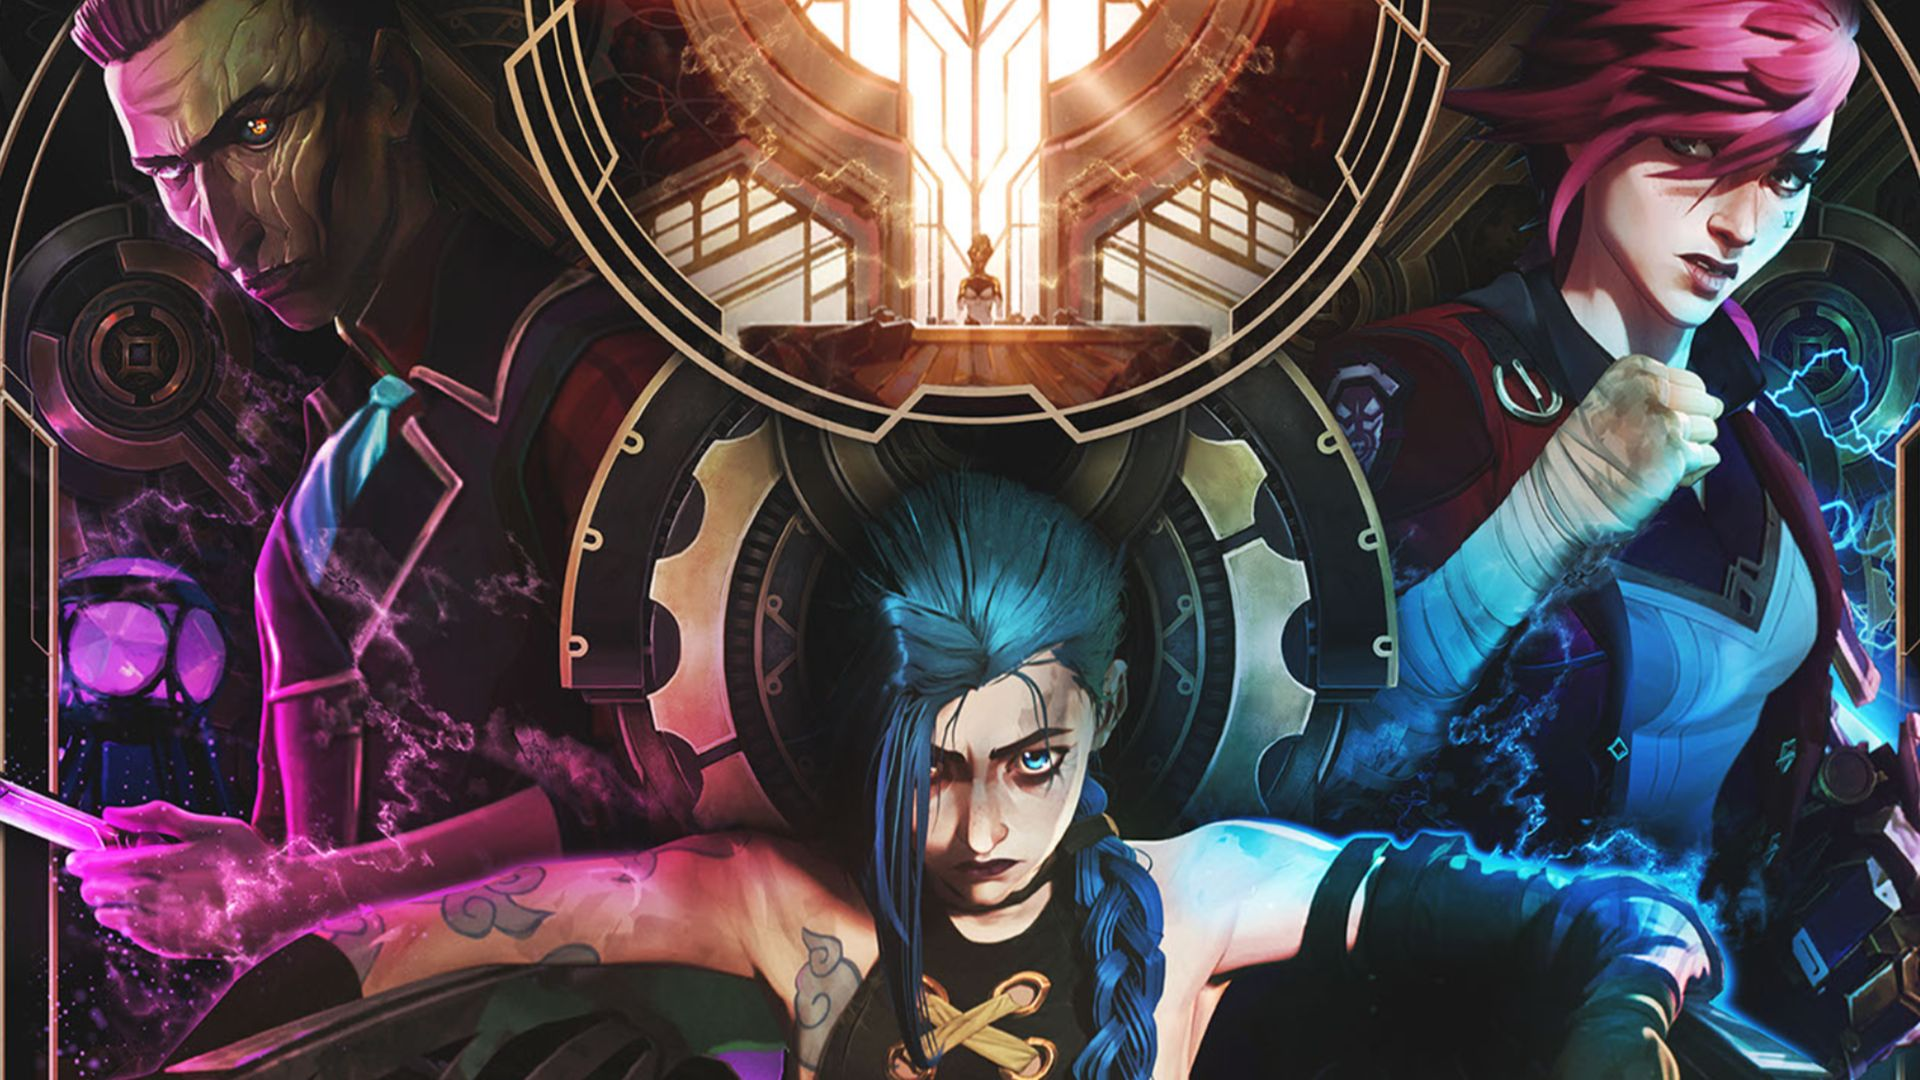

In [9]:
# Mostrar la imagen en el notebook
print("La imagen que le vamos a mostrar al modelo:")
display(Image(filename=str(IMG_PATH), width=700))

### Preguntando al modelo qué ve 👁️

La imagen se pasa como una ruta local. Ollama la codifica en base64 internamente — sin necesidad de subirla a ningún servidor.
Pasamos la ruta absoluta para mayor compatibilidad.


In [10]:
IMG_ABS = str(IMG_PATH.resolve())

prompt_vision = "Describe detalladamente lo que ves en esta imagen: personajes, colores, ambiente y estilo artístico."

print("PROMPT:")
print(f"  {prompt_vision}\n")
print("RESPUESTA DE GEMMA 4:")
print("─" * 60)

r = ollama.chat(
    model=MODEL,
    messages=[{
        "role": "user",
        "content": prompt_vision,
        "images": [IMG_ABS],
    }],
    options={"temperature": 1.0, "top_p": 0.95, "top_k": 64}
)

# Imprimir con wrapping limpio
for linea in textwrap.wrap(r.message.content, width=80):
    print(linea)
print("─" * 60)


PROMPT:
  Describe detalladamente lo que ves en esta imagen: personajes, colores, ambiente y estilo artístico.

RESPUESTA DE GEMMA 4:
────────────────────────────────────────────────────────────
Esta es una descripción detallada y estructurada de la imagen, abordando
personajes, colores, ambiente y estilo artístico.  ***  ### 🌟 Descripción
General  La imagen es una vibrante y altamente estilizada composición de arte
digital que evoca la estética de una *splash page* de novela gráfica de ciencia
ficción o fantasía épica. La sensación general es de inmenso poder, conflicto
inminente y un trasfondo tecnológico o arcano de gran magnitud. La composición
está diseñada para hacer que los personajes se sientan centrales, emanan fuerza
y están en un momento de máxima acción.  ### 👥 Los Personajes  Hay tres
personajes principales, cada uno con un estilo y una energía muy definidos:  1.
**La Figura Central (Foco Principal):** Es una mujer joven con el cabello largo
y sedoso de un vibrante color a

### Pregunta de seguimiento: razonamiento sobre la imagen

In [11]:
# Segunda pregunta sobre la misma imagen — demostrar razonamiento
prompt_razonamiento = "¿Qué relación emocional o narrativa percibes entre los tres personajes principales?"

print("PROMPT DE SEGUIMIENTO:")
print(f"  {prompt_razonamiento}\n")
print("RESPUESTA DE GEMMA 4:")
print("─" * 60)

r2 = ollama.chat(
    model=MODEL,
    messages=[{
        "role": "user",
        "content": prompt_razonamiento,
        "images": [IMG_ABS],
    }],
    options={"temperature": 1.0, "top_p": 0.95, "top_k": 64}
)

for linea in textwrap.wrap(r2.message.content, width=80):
    print(linea)
print("─" * 60)


PROMPT DE SEGUIMIENTO:
  ¿Qué relación emocional o narrativa percibes entre los tres personajes principales?

RESPUESTA DE GEMMA 4:
────────────────────────────────────────────────────────────
Esta es una pregunta excelente que requiere un análisis puramente
interpretativo, ya que no tenemos contexto de la obra. Sin embargo, basándonos
únicamente en su composición visual, la intensidad de sus expresiones y la
dinámica del fondo, se pueden construir varias hipótesis muy potentes sobre la
relación entre ellos.  En términos generales, la relación que percibo no es de
amistad casual, sino de **interdependencia vital**, marcada por una mezcla
intensa de **conflicto, deber y un destino compartido.** Son un trío funcional,
donde la fuerza de uno depende del equilibrio de los otros dos.  Aquí desgloso
los roles y la tensión narrativa que percibo:  ***  ### 1. La Tensión Central:
Destino Compartido y Complementariedad  La atmósfera es demasiado dramática y
grandiosa para un grupo sin un objetiv

## 7. ¿Qué aprendimos hoy?

| Concepto | Resumen |
|----------|---------|
| **LLM local** | Un modelo que corre en tu hardware, sin API ni internet. Ollama gestiona CUDA/Metal automáticamente. |
| **Cuantización** | Reducir la precisión numérica (32→4 bits) para que el modelo quepa en hardware consumer. Calidad ≈ 95%. |
| **API estándar** | Roles `system` / `user` / `assistant`. Es el mismo formato de OpenAI — aprenderlo hoy = usarlo en cualquier LLM mañana. |
| **Temperature** | Controla la aleatoriedad. Para RAG: usa baja (0.1-0.3). Para creatividad: usa alta (1.0-1.5). |
| **Contexto multi-turno** | No hay memoria real — el modelo recibe el historial completo en cada llamada. |
| **Multimodal** | Gemma 4 procesa texto + imagen de forma nativa, sin configuración extra ni modelos separados. |
